--- Outlier Detection and Removal ---
Detected outliers: [-50, 80, 100, 150]
Lower bound: -0.12, Upper bound: 38.88
Original data size: 20
Data size after removal: 16


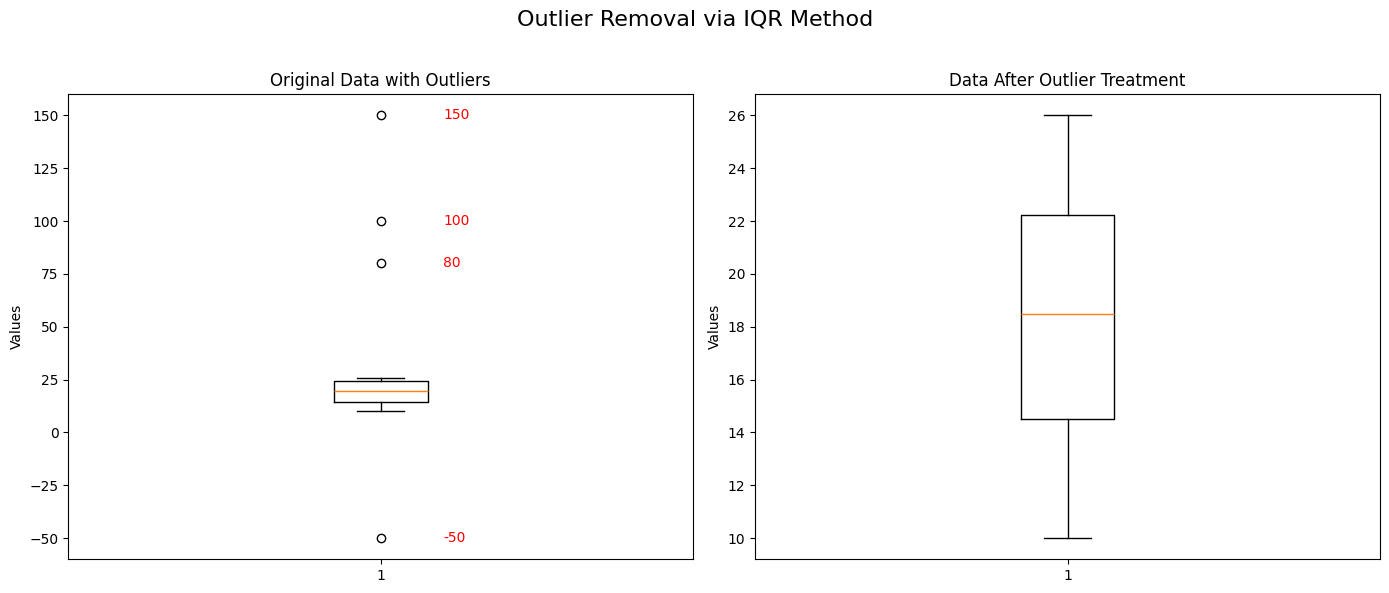


--- Outlier Detection and Replacement ---
Detected outliers: [-50, 80, 100, 150]
Lower bound: -0.12, Upper bound: 38.88
Original data size: 20
Data size after replacement: 20
Replaced outliers with: 18.0


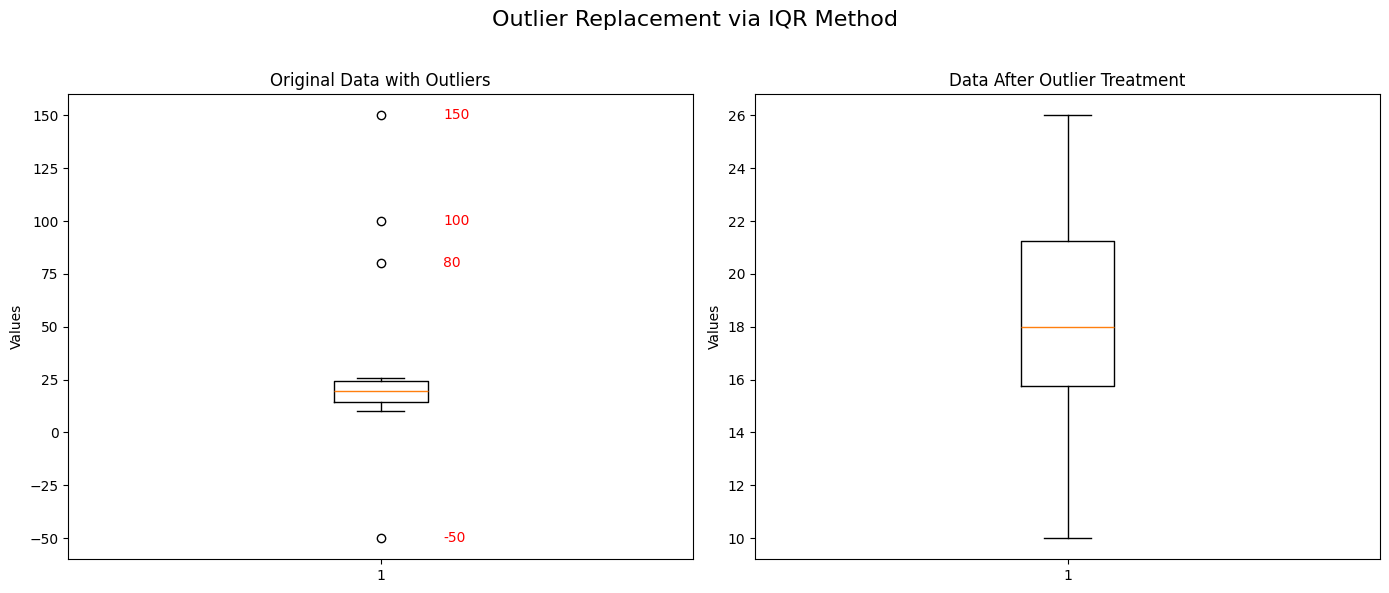

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def detect_and_handle_outliers(data, method='remove', replace_value=None):
    """
    Detects and handles outliers in a dataset using the IQR method.

    Args:
        data (np.array or list): The input dataset.
        method (str): The method to handle outliers.
                      'remove' to delete them from the dataset.
                      'replace' to substitute them with a specified value.
        replace_value (float or int): The value to replace outliers with.
                                      Required if method is 'replace'.

    Returns:
        np.array: The dataset with outliers handled.
        list: A list of the detected outlier values.
    """
    # Convert data to a numpy array for easier calculations
    data = np.array(data)
    
    # Calculate the first quartile (Q1) and third quartile (Q3)
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    
    # Calculate the Interquartile Range (IQR)
    IQR = Q3 - Q1
    
    # Define the lower and upper bounds for outlier detection
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify outliers
    outliers_indices = np.where((data < lower_bound) | (data > upper_bound))[0]
    outliers = data[outliers_indices].tolist()
    
    print(f"Detected outliers: {outliers}")
    print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")

    if method == 'remove':
        # Remove outliers by keeping all non-outlier data points
        cleaned_data = np.delete(data, outliers_indices)
        
    elif method == 'replace':
        if replace_value is None:
            # If no replacement value is provided, use the median of the non-outlier data
            non_outlier_data = np.delete(data, outliers_indices)
            replace_value = np.median(non_outlier_data)
        
        # Replace outliers with the specified value
        cleaned_data = np.copy(data)
        cleaned_data[outliers_indices] = replace_value
    
    else:
        raise ValueError("Method must be 'remove' or 'replace'.")
    
    return cleaned_data, outliers

def visualize_data(original_data, modified_data, title, outliers=None):
    """
    Visualizes the data before and after outlier treatment using box plots.

    Args:
        original_data (np.array): The original dataset.
        modified_data (np.array): The dataset with outliers handled.
        title (str): The title for the plot.
        outliers (list): A list of the detected outliers for annotation.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(title, fontsize=16)

    # Box plot for original data
    axes[0].boxplot(original_data)
    axes[0].set_title('Original Data with Outliers')
    axes[0].set_ylabel('Values')

    # Add text labels for outliers on the original plot
    if outliers:
        for outlier in outliers:
            axes[0].text(1.1, outlier, f'{outlier}', ha='left', va='center', color='red')

    # Box plot for cleaned data
    axes[1].boxplot(modified_data)
    axes[1].set_title('Data After Outlier Treatment')
    axes[1].set_ylabel('Values')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# --- Main Execution ---
if __name__ == "__main__":
    # Sample dataset with some clear outliers
    dataset = [
        10, 12, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
        -50, 80, 100, 150 # These are the outliers
    ]
    
    print("--- Outlier Detection and Removal ---")
    
    # Case 1: Remove the outliers
    data_removed, detected_outliers_removed = detect_and_handle_outliers(dataset, method='remove')
    print("Original data size:", len(dataset))
    print("Data size after removal:", len(data_removed))
    
    # Visualize the data before and after removal
    visualize_data(np.array(dataset), data_removed, "Outlier Removal via IQR Method", detected_outliers_removed)

    print("\n--- Outlier Detection and Replacement ---")
    
    # Case 2: Replace the outliers with the median of the non-outlier data
    data_replaced, detected_outliers_replaced = detect_and_handle_outliers(dataset, method='replace')
    print("Original data size:", len(dataset))
    print("Data size after replacement:", len(data_replaced))
    print("Replaced outliers with:", np.median(data_replaced))

    # Visualize the data before and after replacement
    visualize_data(np.array(dataset), data_replaced, "Outlier Replacement via IQR Method", detected_outliers_replaced)

Sample Dataset:
   Feature_A  Feature_B  Feature_C  Feature_D Category
0         10        5.0          2        100        A
1         12        6.0          3         95        B
2         15        7.5          5         80        A
3         18        9.0          8         70        B
4         20       10.0         10         65        A
5         25       12.5         11         50        B
6         28       14.0         13         45        A
7         30       15.0         14         40        B


Calculated Correlation Matrix:
           Feature_A  Feature_B  Feature_C  Feature_D
Feature_A   1.000000   1.000000   0.985139  -0.991840
Feature_B   1.000000   1.000000   0.985139  -0.991840
Feature_C   0.985139   0.985139   1.000000  -0.989942
Feature_D  -0.991840  -0.991840  -0.989942   1.000000


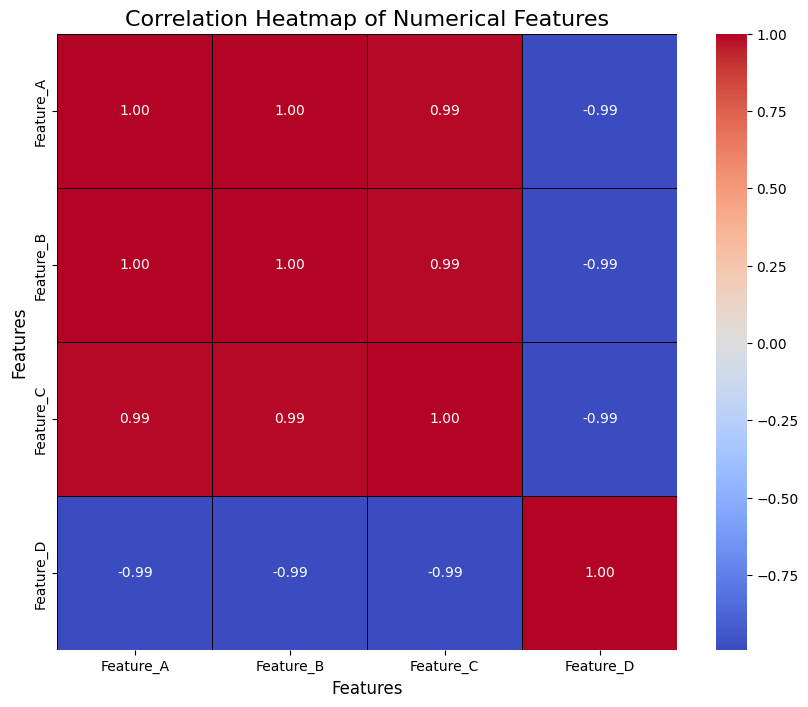

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def create_and_visualize_correlation_matrix(df):
    """
    Calculates the correlation matrix for numerical columns in a DataFrame
    and visualizes it as a heatmap.

    Args:
        df (pd.DataFrame): The input DataFrame.
    """
    # Select only the numerical columns for correlation analysis
    numerical_df = df.select_dtypes(include=np.number)
    
    if numerical_df.empty:
        print("No numerical columns found in the dataset to calculate correlations.")
        return
        
    # Calculate the correlation matrix
    correlation_matrix = numerical_df.corr()
    
    print("Calculated Correlation Matrix:")
    print(correlation_matrix)
    
    # Create the heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f",
                linewidths=.5, linecolor='black')
    
    plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
    plt.xlabel('Features', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.show()

# --- Main Execution ---
if __name__ == "__main__":
    # Create a sample dataset. In a real-world scenario, you would
    # use pd.read_csv(), pd.read_excel(), etc., to load your data.
    data = {
        'Feature_A': [10, 12, 15, 18, 20, 25, 28, 30],
        'Feature_B': [5, 6, 7.5, 9, 10, 12.5, 14, 15],
        'Feature_C': [2, 3, 5, 8, 10, 11, 13, 14],
        'Feature_D': [100, 95, 80, 70, 65, 50, 45, 40],
        'Category': ['A', 'B', 'A', 'B', 'A', 'B', 'A', 'B']
    }
    df = pd.DataFrame(data)
    
    print("Sample Dataset:")
    print(df)
    print("\n" + "="*50 + "\n")
    
    # Call the function to calculate and visualize the correlation matrix
    create_and_visualize_correlation_matrix(df)


In [ ]:
import pandas as pd
import numpy as np

def extract_date_features(df, date_column):
    """
    Extracts meaningful features (year, month, day, day of week, weekend)
    from a date column.

    Args:
        df (pd.DataFrame): The input DataFrame.
        date_column (str): The name of the date column to process.

    Returns:
        pd.DataFrame: The DataFrame with new date features.
    """
    # Ensure the date column is in datetime format
    df[date_column] = pd.to_datetime(df[date_column])
    
    # Extract features
    df['year'] = df[date_column].dt.year
    df['month'] = df[date_column].dt.month
    df['day'] = df[date_column].dt.day
    df['day_of_week'] = df[date_column].dt.dayofweek
    
    # Check if it's a weekend (dayofweek >= 5 for Saturday and Sunday)
    df['is_weekend'] = df['day_of_week'] >= 5
    
    return df

def calculate_date_difference(df, start_date_column, end_date_column, new_column_name='days_difference'):
    """
    Calculates the difference in days between two date columns.

    Args:
        df (pd.DataFrame): The input DataFrame.
        start_date_column (str): The name of the start date column.
        end_date_column (str): The name of the end date column.
        new_column_name (str): The name for the new column with the difference.

    Returns:
        pd.DataFrame: The DataFrame with the new difference column.
    """
    # Ensure the date columns are in datetime format
    df[start_date_column] = pd.to_datetime(df[start_date_column])
    df[end_date_column] = pd.to_datetime(df[end_date_column])
    
    # Calculate the difference and convert to days
    df[new_column_name] = (df[end_date_column] - df[start_date_column]).dt.days
    
    return df

# --- Main Execution ---
if __name__ == "__main__":
    # Create a sample dataset with date columns
    data = {
        'event_id': range(5),
        'start_date': pd.to_datetime(['2023-01-01', '2023-01-05', '2023-02-10', '2023-03-15', '2023-04-20']),
        'end_date': pd.to_datetime(['2023-01-05', '2023-01-12', '2023-02-28', '2023-03-15', '2023-04-25'])
    }
    df = pd.DataFrame(data)
    
    print("Original DataFrame:")
    print(df)
    print("\n" + "="*50 + "\n")
    
    # 1. Extract features from the 'start_date' column
    df_with_features = extract_date_features(df.copy(), 'start_date')
    print("DataFrame with extracted date features:")
    print(df_with_features)
    print("\n" + "="*50 + "\n")
    
    # 2. Calculate the difference in days between 'end_date' and 'start_date'
    df_with_diff = calculate_date_difference(df.copy(), 'start_date', 'end_date')
    print("DataFrame with days difference between start and end dates:")
    print(df_with_diff)
    print("\n" + "="*50 + "\n")
